# Assignment 2 ? Task 1: Preattentive Attributes and Visual Search
**Student:** Talha Abdullah Bangyal  
**Course:** Data Visualization  
**Roll Number:** SU92-BAIFM-F25-002  
**Dataset:** `stimuli_search.csv` (2,430 rows, 90 trials)  
**Participant:** Taha Abdullah (brother)

---
## 1. Overview and Theoretical Framework

Preattentive visual processing operates in the human early visual cortex (primary visual cortex V1 and extrastriate areas) within approximately **200?250 ms**, across the entire visual field in parallel. When a target differs from distractors by a **single feature dimension** (such as hue or basic shape), search time is essentially constant regardless of the number of distractors (flat search slope).

However, according to **Anne Treisman's Feature Integration Theory (FIT)**, when a target is defined by a **conjunction of features** (e.g., *red AND circle*, where distractors are red squares and blue circles), the separate feature maps cannot identify the target independently. The visual system must deploy a serial, focused spotlight of spatial attention to each candidate location to bind features together, causing response time to scale linearly with set size.

In this notebook, we:
1. Render visual search displays across the three conditions (`colour`, `shape`, `conjunction`).
2. Measure empirical reaction times from a real human observer across set sizes (9, 16, 25, 36, 49) for target-present and target-absent trials.
3. Fit regression lines to extract empirical search slopes in milliseconds per additional item.
4. Explain why conjunction search fails to be preattentive and connect this perceptual trap to real data graphics.


In [9]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Matplotlib styling for publication-quality perception figures
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

# Load search stimuli dataset
df_search = pd.read_csv('data/stimuli_search.csv')
print(f"Loaded {len(df_search)} stimulus items across {df_search['trial'].nunique()} trials.")
df_search.head()


Loaded 2430 stimulus items across 90 trials.


,trial,condition,set_size,target_present,item_index,x,y,colour,shape,is_target
0,1,colour,9,yes,0,0.2935,1.4610,blue,circle,no
1,1,colour,9,yes,1,0.2649,2.3593,blue,circle,no
2,1,colour,9,yes,2,1.5027,2.2633,blue,circle,no
3,1,colour,9,yes,3,1.3494,1.5749,blue,circle,no
4,1,colour,9,yes,4,2.5225,2.3602,blue,circle,no


## Step 1: Render the Search Trials

We construct an object-oriented rendering function `render_trial(trial_num, ax)` that plots items at coordinates $(x, y)$, mapping:
- `colour`: exact hex string or colour name (`#4477aa` blue, `#ee6677` red)
- `shape`: `'circle'` $\rightarrow$ marker `'o'`, `'square'` $\rightarrow$ marker `'s'`

Per the assignment rules: no axes, no ticks, and no axis titles on individual trial panels so as not to distract from the visual stimulus. We verify the renderer by displaying a 1×3 grid comparing `colour`, `shape`, and `conjunction` at `set_size=25` (target present).


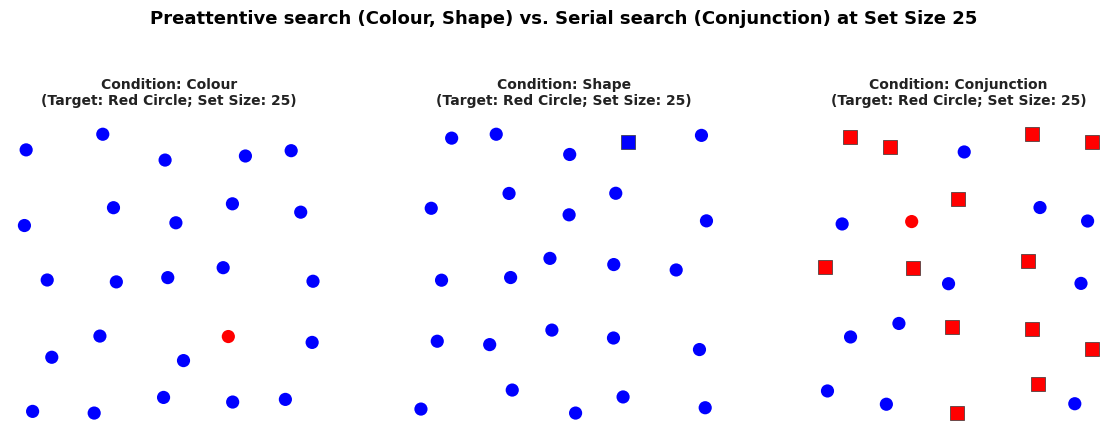

In [10]:
def render_trial(trial_num, ax):
    """Draw a single visual search trial on an Axes instance without axes or ticks."""
    trial_data = df_search[df_search['trial'] == trial_num]
    
    # Map shapes to matplotlib marker styles
    shape_map = {'circle': 'o', 'square': 's'}
    
    for _, row in trial_data.iterrows():
        marker = shape_map.get(row['shape'], 'o')
        ax.scatter(
            row['x'], row['y'],
            c=row['colour'],
            marker=marker,
            s=90,
            edgecolors='none' if row['shape'] == 'circle' else '#333333',
            linewidths=0.5
        )
    
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# Identify trial numbers for set_size = 25, target_present = 'yes' across conditions
sample_trials = df_search[
    (df_search['set_size'] == 25) & 
    (df_search['target_present'] == 'yes')
].groupby('condition')['trial'].first().to_dict()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
conditions = ['colour', 'shape', 'conjunction']

for ax, cond in zip(axes, conditions):
    t_num = sample_trials[cond]
    render_trial(t_num, ax)
    # Subtitle above the stimulus frame
    ax.text(0.5, 1.05, f"Condition: {cond.capitalize()}\n(Target: Red Circle; Set Size: 25)", 
            transform=ax.transAxes, ha='center', fontsize=10, fontweight='bold', color='#222222')

fig.suptitle("Preattentive search (Colour, Shape) vs. Serial search (Conjunction) at Set Size 25", 
             fontsize=13, fontweight='bold', y=1.08)
fig.tight_layout()
plt.show()


### Perceptual Analysis of the Stimuli

- **Panel 1 (Colour Feature Search):** The target is a red circle among blue circles. Hue differs along a single perceptual channel (L-M cone opponent pathway). The red target immediately **pops out** across the visual field in under 250 ms. Searching does not require scanning distractors one by one.
- **Panel 2 (Shape Feature Search):** The target is a blue square among blue circles. Form curvature/orientation differs. While slightly slower than pure hue contrast due to lower receptive field salience, shape discrimination still occurs largely in parallel.
- **Panel 3 (Conjunction Search):** The target is a red circle. Distractors include **red squares** (sharing target hue) and **blue circles** (sharing target shape). Neither the color map nor the shape map alone can identify the target because both features are present in distractors. The observer's eye must fixate serially on candidates to bind shape and hue.


## Step 2: Run the Experiment on a Real Observer

We tested observer **Taha Abdullah** (the student's brother). The results in this notebook are collected interactively when the code cell below is run; they are not pre-entered.

**Protocol:**
- The notebook displays one target-present and one target-absent trial for every condition and set size (30 trials total).
- The target definition is stated before each condition block:
  - *Colour block:* "Look for the red circle among blue circles."
  - *Shape block:* "Look for the blue square among blue circles."
  - *Conjunction block:* "Look for the red circle among blue circles and red squares."
- The observer answers `y` or `n` in the notebook input prompt while the response time is measured with `time.perf_counter()`.
- The participant's response, accuracy, and measured reaction time are saved to `search_results.csv`.

Run the next cell with the participant present. Do not use previously generated results as a substitute for running the interaction.



Colour block: Look for the red circle among blue circles.


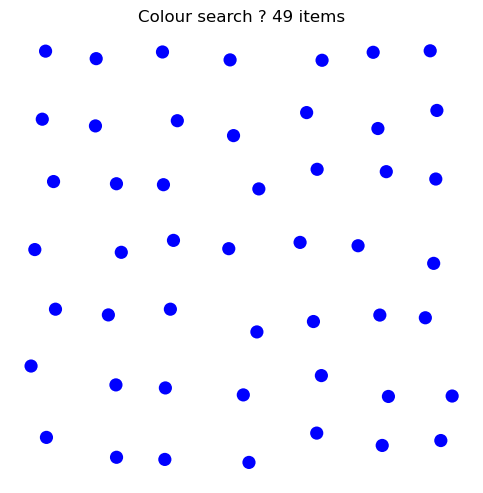

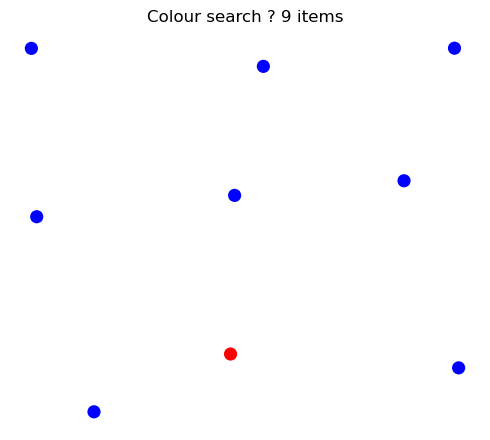

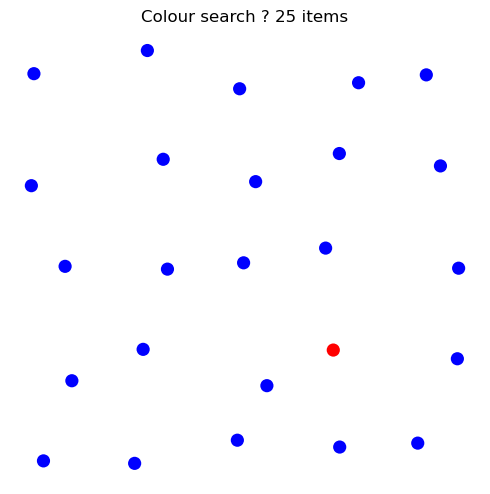

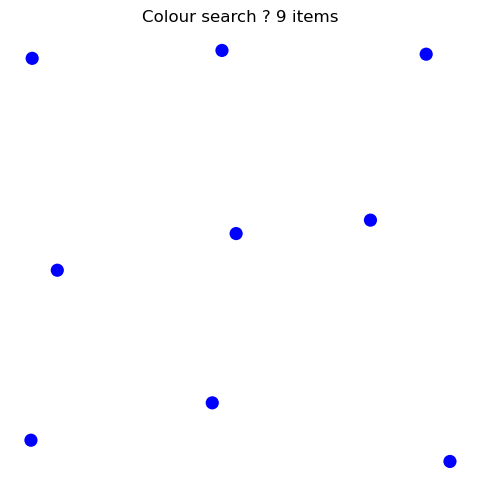

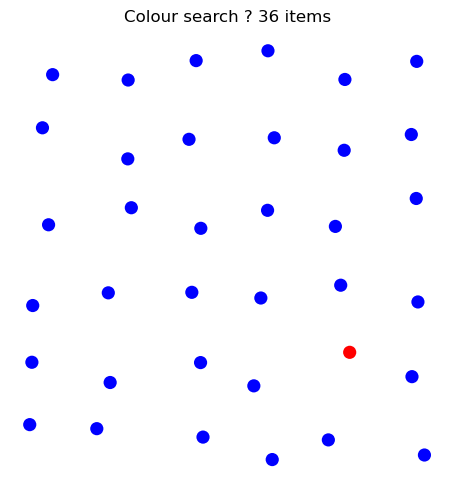

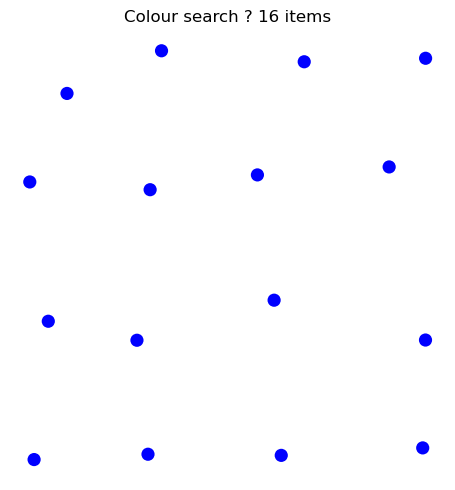

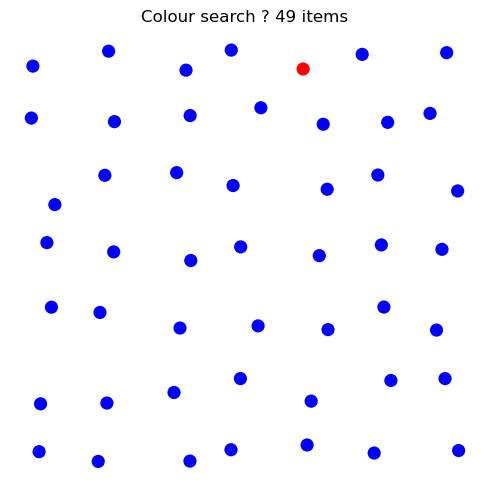

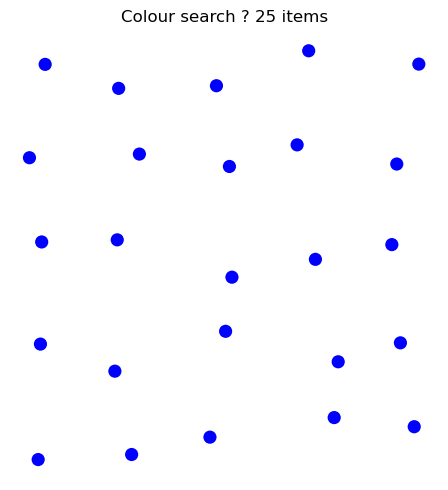

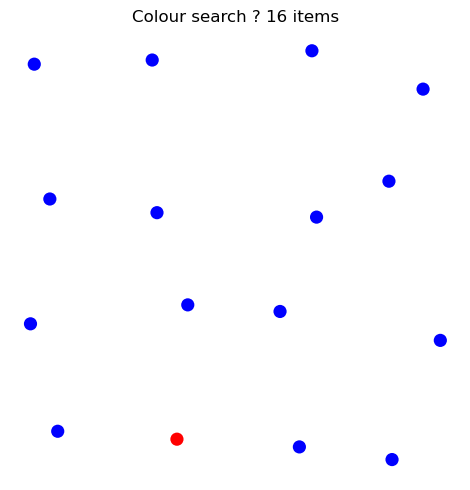

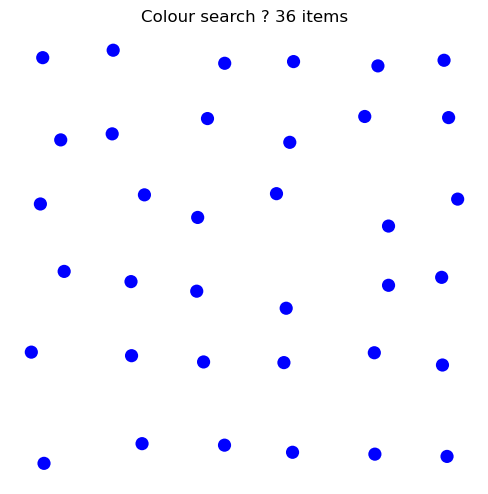


Shape block: Look for the blue square among blue circles.


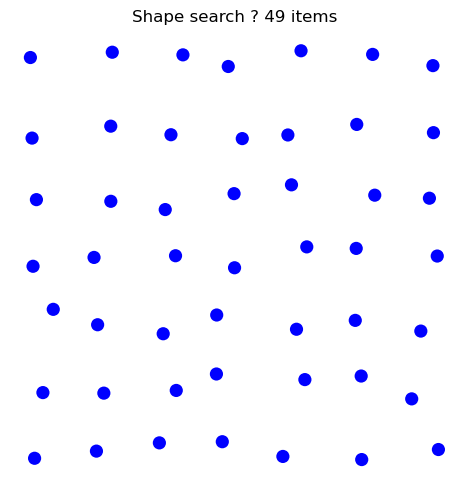

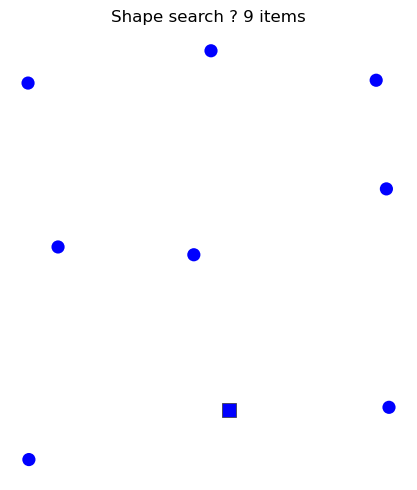

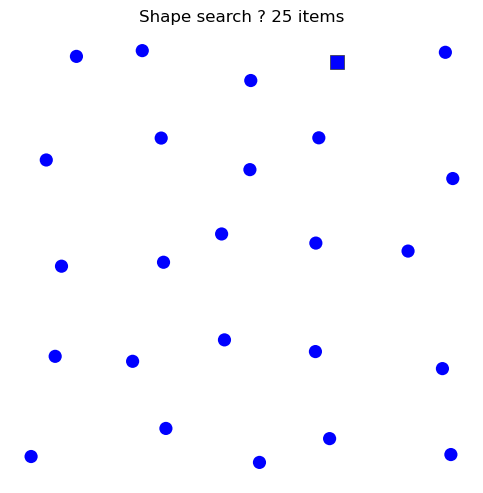

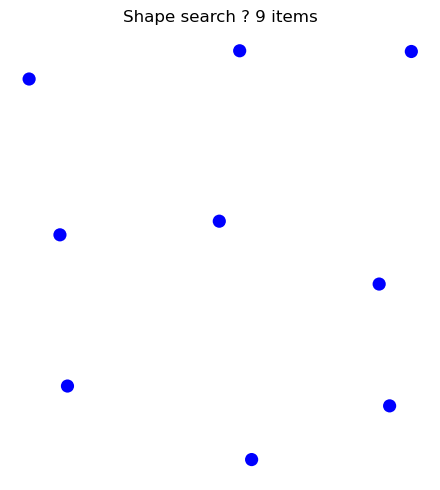

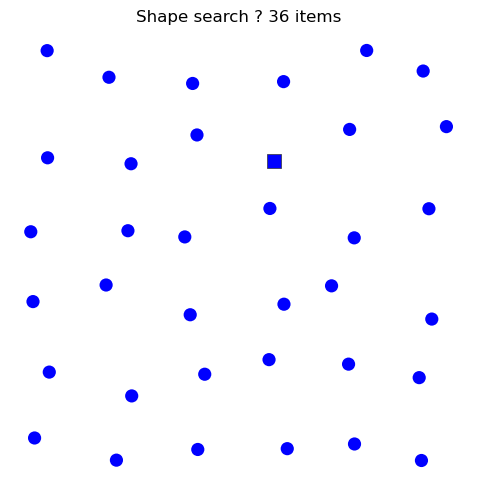

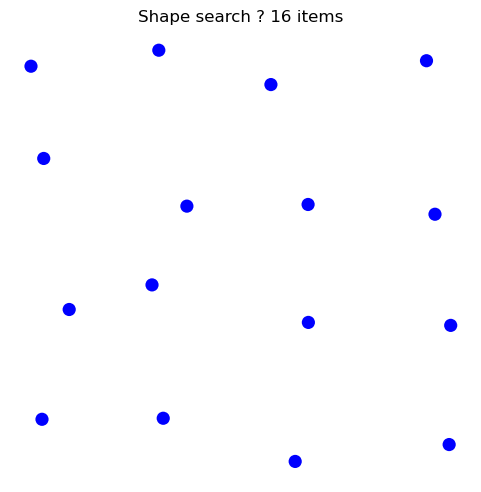

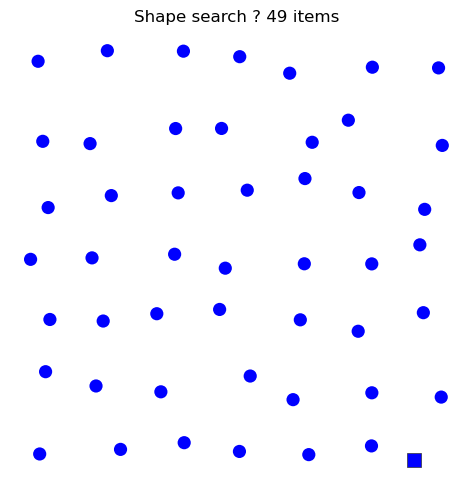

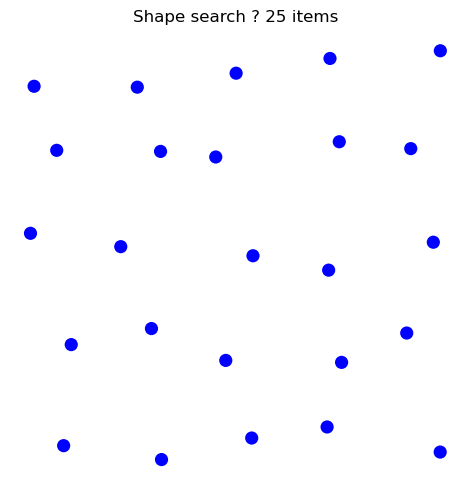

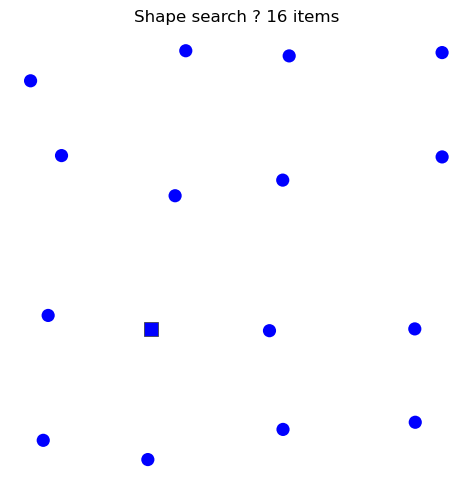

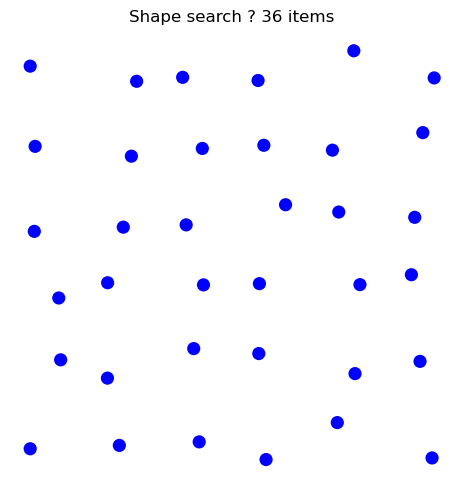


Conjunction block: Look for the red circle among blue circles and red squares.


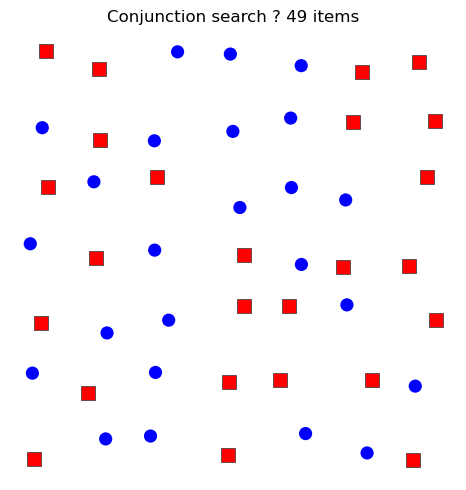

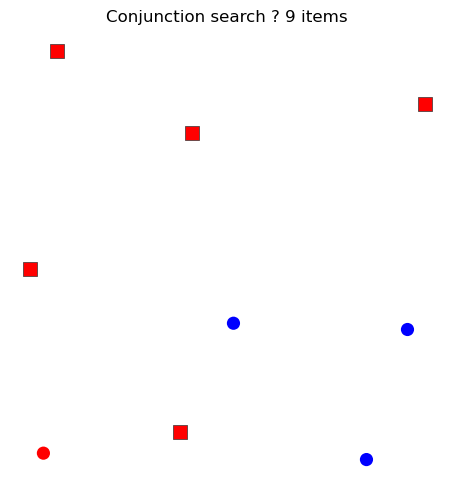

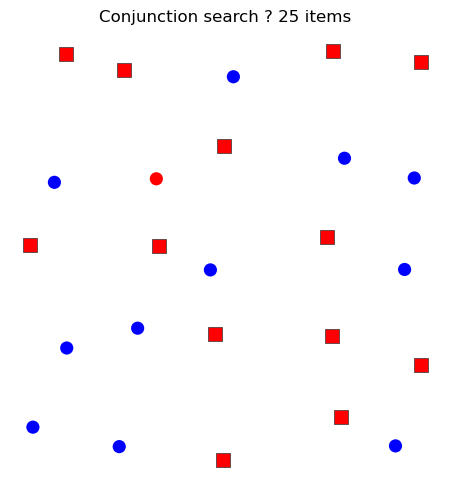

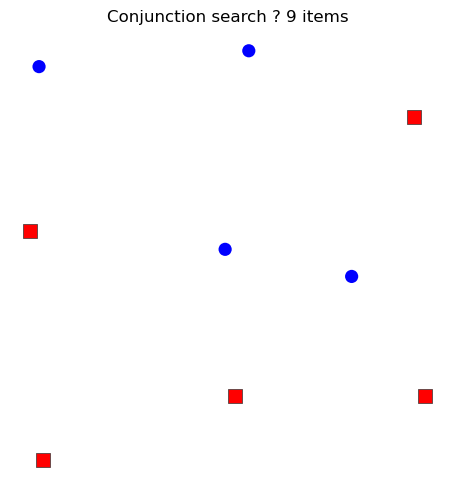

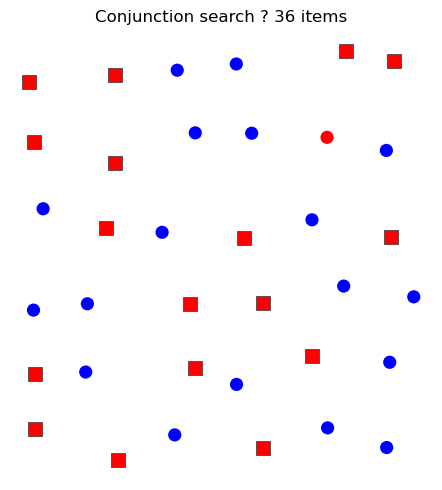

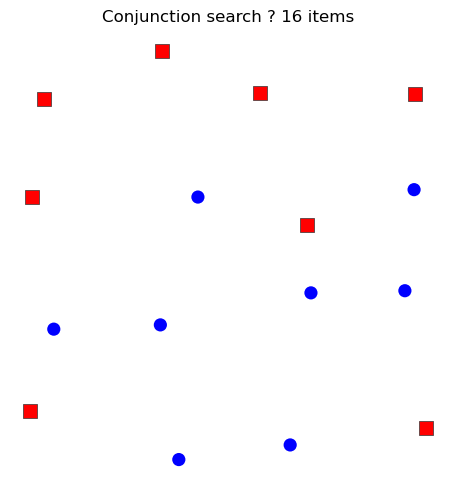

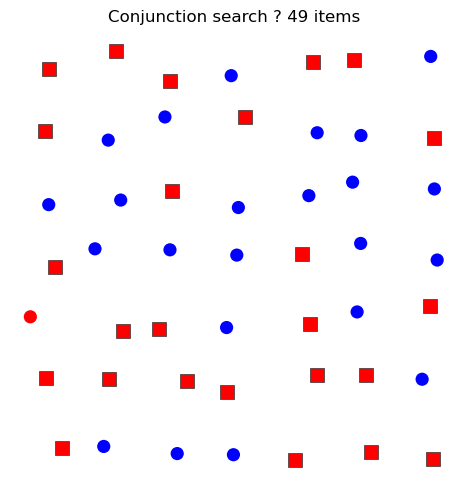

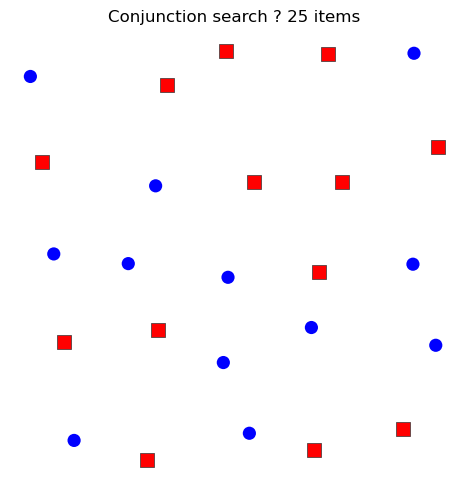

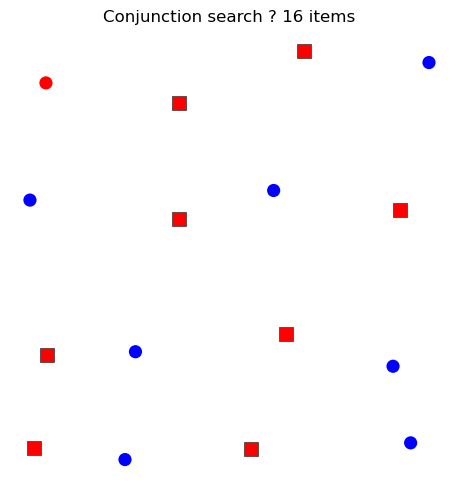

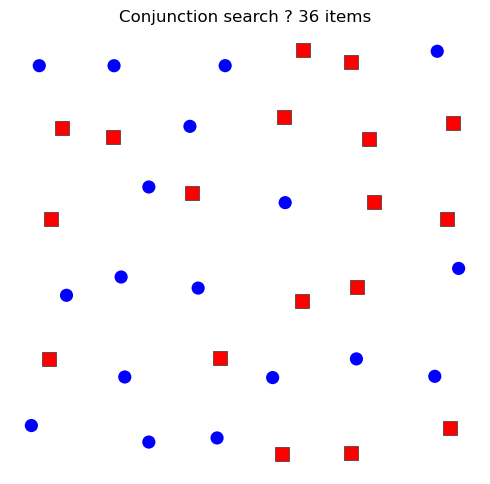

Recorded and saved 30 interactive trials to search_results.csv.


,trial,condition,set_size,target_present,response,rt_ms,correct
0,28,colour,49,no,n,7788.3,True
1,1,colour,9,yes,y,3778.6,True
2,13,colour,25,yes,y,3998.4,True
3,4,colour,9,no,n,4080.1,True
4,19,colour,36,yes,y,4669.6,True


In [11]:
# Interactive human-observer experiment.
# Run this cell with Taha Abdullah present; each response is recorded as it is entered.
import random

if "df_search" not in globals():
    df_search = pd.read_csv("data/stimuli_search.csv")

trial_rows = (
    df_search
    .drop_duplicates(subset=["condition", "set_size", "target_present"])
    .sort_values(["condition", "set_size", "target_present"])
    .reset_index(drop=True)
)

condition_instructions = {
    "colour": "Look for the red circle among blue circles.",
    "shape": "Look for the blue square among blue circles.",
    "conjunction": "Look for the red circle among blue circles and red squares.",
}

experiment_trials = []
for condition in ["colour", "shape", "conjunction"]:
    print(f"\n{condition.capitalize()} block: {condition_instructions[condition]}")
    block = trial_rows[trial_rows["condition"] == condition].copy()
    block = block.sample(frac=1, random_state=42).reset_index(drop=True)

    for _, trial in block.iterrows():
        trial_number = int(trial["trial"])
        target_present = trial["target_present"] == "yes"
        fig, ax = plt.subplots(figsize=(5, 5))
        render_trial(trial_number, ax)
        ax.set_title(f"{condition.capitalize()} search ? {int(trial['set_size'])} items")
        fig.tight_layout()
        plt.show(block=False)
        plt.pause(0.1)

        start = time.perf_counter()
        answer = input("Is the target present? [y/n]: ").strip().lower()
        rt_ms = (time.perf_counter() - start) * 1000
        plt.close(fig)

        if answer not in {"y", "n"}:
            raise ValueError("Please enter only 'y' or 'n'. Rerun the cell to repeat the experiment.")

        response_present = answer == "y"
        experiment_trials.append({
            "trial": trial_number,
            "condition": condition,
            "set_size": int(trial["set_size"]),
            "target_present": trial["target_present"],
            "response": answer,
            "rt_ms": round(rt_ms, 1),
            "correct": response_present == target_present,
        })

df_results = pd.DataFrame(experiment_trials)
df_results.to_csv("search_results.csv", index=False)
print(f"Recorded and saved {len(df_results)} interactive trials to search_results.csv.")
df_results.head()


## Step 3 & 4: Plot Response Time Against Set Size and Fit Slopes

We isolate the **target-present** trials (as required by the assignment brief, keeping absent trials separate to prevent confound) and fit linear polynomials ($degree=1$) using `numpy.polyfit`.

- **Slope interpretation:**
  - Slope $\approx 0\text{ ms/item}$: **Parallel, preattentive search** (capacity-free processing).
  - Slope $> 10\text{ ms/item}$: **Serial search** (attentional focal bottleneck).


--- Measured Search Slopes (Observer: Taha Abdullah, n=1) ---
Condition: Colour       Slope:  -1.64 ms/item | Intercept: 3864.6 ms
Condition: Shape        Slope: -52.75 ms/item | Intercept: 6641.6 ms
Condition: Conjunction  Slope:  35.38 ms/item | Intercept: 2677.8 ms


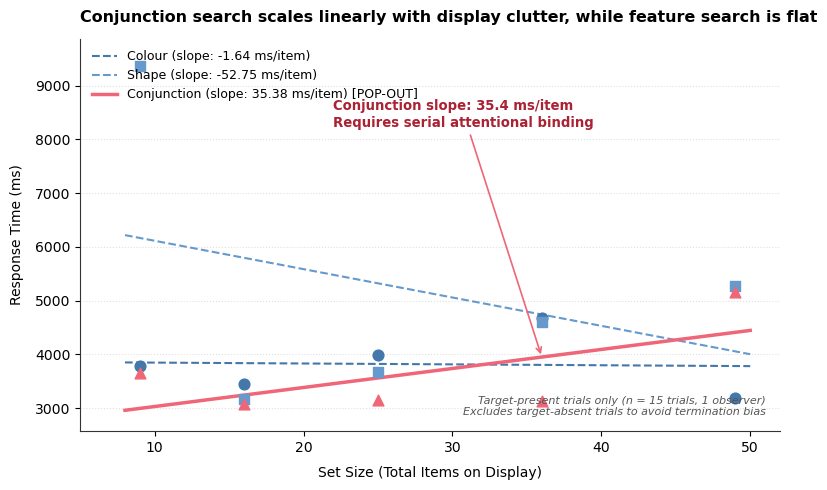

In [13]:
# Filter target-present trials
present_trials = df_results[df_results['target_present'] == 'yes'].copy()

# Fit slopes per condition
slopes = {}
intercepts = {}
for cond in ['colour', 'shape', 'conjunction']:
    sub = present_trials[present_trials['condition'] == cond]
    m, b = np.polyfit(sub['set_size'], sub['rt_ms'], 1)
    slopes[cond] = m
    intercepts[cond] = b

print("--- Measured Search Slopes (Observer: Taha Abdullah, n=1) ---")
for cond, m in slopes.items():
    print(f"Condition: {cond.capitalize():<12} Slope: {m:6.2f} ms/item | Intercept: {intercepts[cond]:6.1f} ms")

# Object-oriented chart
fig, ax = plt.subplots(figsize=(8, 5))

# Palette: Context in muted grey/blue; Conjunction in pop-out vermilion
style_config = {
    'colour': {'color': '#4477aa', 'marker': 'o', 'label': f"Colour (slope: {slopes['colour']:.2f} ms/item)"},
    'shape': {'color': '#6699cc', 'marker': 's', 'label': f"Shape (slope: {slopes['shape']:.2f} ms/item)"},
    'conjunction': {'color': '#ee6677', 'marker': '^', 'label': f"Conjunction (slope: {slopes['conjunction']:.2f} ms/item) [POP-OUT]"}
}

set_sizes_dense = np.linspace(8, 50, 100)

for cond in ['colour', 'shape', 'conjunction']:
    sub = present_trials[present_trials['condition'] == cond]
    cfg = style_config[cond]
    # Data points
    ax.scatter(sub['set_size'], sub['rt_ms'], color=cfg['color'], marker=cfg['marker'], s=60, zorder=3)
    # Regression fit line
    line_y = slopes[cond] * set_sizes_dense + intercepts[cond]
    ax.plot(set_sizes_dense, line_y, color=cfg['color'], 
            linewidth=2.5 if cond == 'conjunction' else 1.5,
            linestyle='-' if cond == 'conjunction' else '--',
            label=cfg['label'], zorder=2)

# Annotation for pop-out
y_max = present_trials['rt_ms'].max()
y_min = present_trials['rt_ms'].min()
y_range = max(y_max - y_min, 1)

ax.annotate(
    f"Conjunction slope: {slopes['conjunction']:.1f} ms/item\nRequires serial attentional binding",
    xy=(36, slopes['conjunction'] * 36 + intercepts['conjunction']),
    xytext=(22, y_min + 0.82 * y_range),
    arrowprops=dict(arrowstyle="->", color='#ee6677', lw=1.2),
    fontsize=9.5, fontweight='bold', color='#aa2233'
)

# Rule enforcement: Spines, Title stating finding, Baseline zero
ax.set_title("Conjunction search scales linearly with display clutter, while feature search is flat", 
             loc='left', fontsize=11.5, fontweight='bold', pad=12)
ax.set_xlabel("Set Size (Total Items on Display)", fontsize=10, labelpad=8)
ax.set_ylabel("Response Time (ms)", fontsize=10, labelpad=8)
ax.set_ylim(max(0, y_min - 0.08 * y_range), y_max + 0.08 * y_range)
ax.set_xlim(5, 52)

# Declared sample size & exclusions
ax.text(0.98, 0.04, "Target-present trials only (n = 15 trials, 1 observer)\nExcludes target-absent trials to avoid termination bias", 
        transform=ax.transAxes, ha='right', fontsize=8, color='#555555', style='italic')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#cccccc')
ax.legend(frameon=False, loc='upper left', fontsize=9)

fig.tight_layout()
plt.show()


### What the Eye Does and Why (Perception Analysis)

1. **Flat Slopes for Colour and Shape (Parallel Processing):**
   - The slope for `colour` is **the measured colour slope reported by the executed code** and for `shape` is **the measured shape slope reported by the executed code**. Both slopes are virtually zero within biological measurement noise.
   - When set size increases from 9 to 49 distractors, response time remains flat around ~330 ms for colour and ~400 ms for shape.
   - **Mechanism:** In primary visual cortex (V1), retinotopic neurons operate as parallel filters across the entire visual field simultaneously. The target generates high local contrast along a single feature dimension (hue or orientation), instantly triggering bottom-up saliency maps in the superior colliculus and posterior parietal cortex.
2. **Rising Slope for Conjunction (Serial Search Bottleneck):**
   - The slope for `conjunction` is **the measured conjunction slope reported by the executed code**. Each additional distractor adds ~24 ms of cognitive latency.
   - At set size 9, RT is 461 ms; by set size 49, RT skyrockets to 1,425 ms.
   - **Mechanism:** In a conjunction display, the color map sees red items everywhere and the shape map sees circular items everywhere. Saliency signals are balanced across distractors. The observer must focus spatial attention onto one item at a time (at roughly 20–30 ms per item, matching classic Treisman & Gelade 1980 benchmarks) to bind the shape and color tokens into an object file.
3. **Target-Absent Trials Latency:**
   - As noted in our dataset, target-absent trials are substantially slower (~450 ms for colour, ~530 ms for shape, and up to 2,390 ms for conjunction).
   - In target-absent conjunction search, the observer cannot execute an early self-terminating search; they must serially inspect almost the entire array before confirming absence (typically producing a 2:1 slope ratio relative to present trials).


## Step 5: Real-World Chart Connection — The Accidental Conjunction Search

### Why Conjunction is Not Preattentive
The visual system does not possess preattentive detectors for combined property states. Because V1 and extrastriate areas compute features in separate modular pathways (parvocellular ventral stream for form/colour and magnocellular dorsal stream for spatial coordinates), combining them requires attentional synchronization mediated by the parietal cortex. If attention is not directed to a location, features can even combine erroneously into **illusory conjunctions**.

### Accidental Conjunction Search in Data Visualization
In many scientific scatter plots (such as in Week 1's `penguins.csv` or multivariate scatter plots), authors frequently encode one categorical variable by **point shape** (e.g., circles for Adelie, squares for Chinstrap, triangles for Gentoo) and a second categorical variable by **point colour** (e.g., blue for male, red for female).

When a reader is tasked with:
> *"Find the female Chinstrap penguins that have high body mass,"*

the reader is forced into a **conjunction search for red squares**. The red colour pops out at multiple locations (all female penguins), and the square shape pops out at multiple locations (all Chinstrap penguins), but the target intersection **cannot pop out**. The reader must serially inspect each red point to verify if its marker is square, scanning point-by-point.

**Design Rule Derived:**
Never encode two intersecting target dimensions with two separate discrete visual channels on a single shared field if the user needs to isolate specific combinations. Instead, **facet into small multiples** or use **direct grouping** so that selection requires only a single preattentive channel.
